# 全证券融资买入资金赚钱效应

首个交易日按全市场融资买入额确定累计 80% 的固定样本；样本以 BaoStock 基础信息标注证券类型，后续交易日不换样。

In [1]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mme-matplotlib'))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
SOURCE = ROOT / 'data/source/margin'
DERIVED = ROOT / 'data/derived/margin'

chinese_font_candidates = ['PingFang SC', 'Heiti SC', 'Hiragino Sans GB', 'STHeiti']
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((font for font in chinese_font_candidates if font in installed_fonts), None)
if chinese_font is None:
    raise RuntimeError('未找到可用中文字体，请安装 PingFang SC、Heiti SC 或 Hiragino Sans GB 后重试。')

plt.rcParams['font.sans-serif'] = [chinese_font]
plt.rcParams['axes.unicode_minus'] = False
print(f'使用中文字体：{chinese_font}')

使用中文字体：PingFang SC


In [2]:
margin_path = SOURCE / 'margin_financing_buy.parquet'
sample_path = DERIVED / 'first_day_top80_all_securities.parquet'
prices_path = SOURCE / 'first_day_top80_all_securities_prices.parquet'
for path in [margin_path, sample_path, prices_path]:
    if not path.exists():
        raise FileNotFoundError(f'缺少输入文件：{path}')

margin = pd.read_parquet(margin_path)
sample = pd.read_parquet(sample_path)
prices = pd.read_parquet(prices_path)
margin['trade_date'] = pd.to_datetime(margin['trade_date'])
sample['trade_date'] = pd.to_datetime(sample['trade_date'])
prices['trade_date'] = pd.to_datetime(prices['trade_date'])

assert {'trade_date', 'exchange', 'security_code', 'security_name', 'financing_buy_amount'} <= set(margin.columns)
assert {'exchange', 'security_code', 'security_type', 'rank', 'cumulative_ratio'} <= set(sample.columns)
assert {'trade_date', 'exchange', 'security_code', 'close', 'close_unadjusted', 'volume', 'amount'} <= set(prices.columns)

sample_by_rank = sample.sort_values('rank').reset_index(drop=True)
assert sample_by_rank.cumulative_ratio.iloc[-1] >= 0.8
assert len(sample_by_rank) == 1 or sample_by_rank.cumulative_ratio.iloc[-2] < 0.8

In [3]:
type_summary = (
    sample.groupby(['security_type_order', 'security_type_name'], as_index=False)
    .agg(证券数量=('security_code', 'size'), 融资买入额=('financing_buy_amount', 'sum'))
    .sort_values('security_type_order')
)
type_summary['样本融资买入额占比'] = type_summary['融资买入额'] / type_summary['融资买入额'].sum()
type_summary['基准日'] = sample_by_rank.trade_date.iloc[0].date().isoformat()
overall = pd.DataFrame([{'security_type_order': -1, 'security_type_name': '总体', '证券数量': len(sample_by_rank), '融资买入额': sample_by_rank.financing_buy_amount.sum(), '样本融资买入额占比': 1.0, '基准日': sample_by_rank.trade_date.iloc[0].date().isoformat()}])
type_summary_display = pd.concat([overall, type_summary], ignore_index=True)
readable_sample = sample.rename(columns={
    'security_type_name': '证券类型', 'type_rank': '类型内排名', 'security_code': '证券代码',
    'security_name': '证券简称', 'exchange': '交易所', 'rank': '全样本排名',
    'financing_buy_amount': '基准日融资买入额', 'cumulative_ratio': '基准日累计占比',
})
readable_sample = readable_sample[['证券类型', '类型内排名', '全样本排名', '证券代码', '证券简称', '交易所', '基准日融资买入额', '基准日累计占比']]
display(type_summary_display.drop(columns='security_type_order').style.format({'融资买入额': '{:,.0f}', '样本融资买入额占比': '{:.2%}'}))
readable_sample

,security_type_name,证券数量,融资买入额,样本融资买入额占比,基准日
0,总体,1014,"231,587,029,671",100.00%,2026-01-05
1,股票,951,"214,963,711,654",92.82%,2026-01-05
2,ETF,63,"16,623,318,017",7.18%,2026-01-05


,证券类型,类型内排名,全样本排名,证券代码,证券简称,交易所,基准日融资买入额,基准日累计占比
0,股票,1,1,300476,胜宏科技,SZSE,3627252152,0.012530
1,股票,2,2,002050,三花智控,SZSE,2780581343,0.022136
2,股票,3,3,300308,中际旭创,SZSE,2773718089,0.031718
3,股票,4,4,300502,新易盛,SZSE,2370988542,0.039908
4,股票,5,5,600118,中国卫星,SSE,2135286965,0.047284
...,...,...,...,...,...,...,...,...
1009,ETF,59,888,518850,黄金9999,SSE,73592359,0.770216
1010,ETF,60,936,159883,医疗器械ETF,SZSE,69983500,0.782142
1011,ETF,61,952,159502,标普生物科技ETF,SZSE,68330543,0.785963
1012,ETF,62,984,513300,纳斯达克,SSE,65563045,0.793345


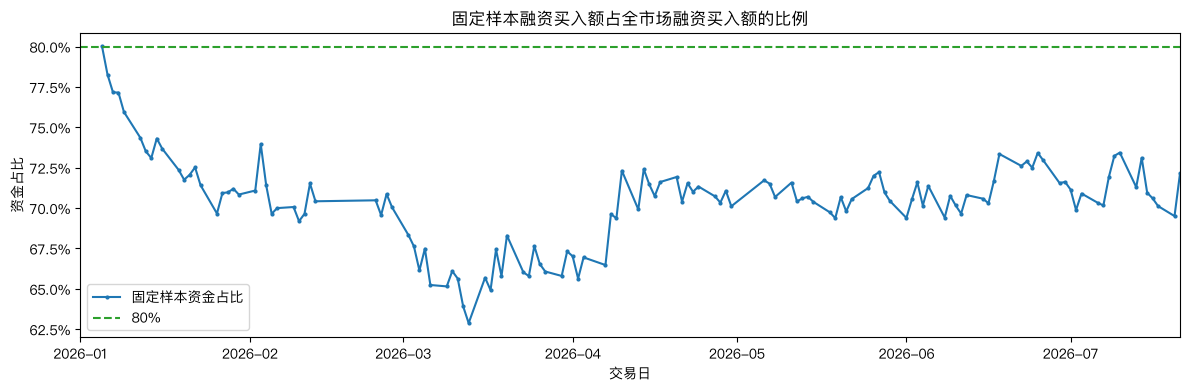

In [4]:
sample_keys = sample[['exchange', 'security_code']].drop_duplicates()
all_daily = margin.groupby('trade_date', as_index=False).financing_buy_amount.sum().rename(columns={'financing_buy_amount': 'all_margin_purchase'})
sample_daily = (
    margin.merge(sample_keys, on=['exchange', 'security_code'], how='inner')
    .groupby('trade_date', as_index=False)
    .agg(sample_margin_purchase=('financing_buy_amount', 'sum'), sample_active_count=('security_code', 'nunique'))
)
coverage = all_daily.merge(sample_daily, on='trade_date', how='left').fillna({'sample_margin_purchase': 0, 'sample_active_count': 0})
coverage['sample_coverage'] = coverage.sample_margin_purchase / coverage.all_margin_purchase
assert coverage.sample_coverage.between(0, 1).all()
coverage.to_parquet(DERIVED / 'all_security_sample_coverage.parquet', index=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(coverage.trade_date, coverage.sample_coverage, marker='o', markersize=2, label='固定样本资金占比')
ax.axhline(0.8, color='tab:green', ls='--', label='80%')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(pd.Timestamp('2026-01-01'), coverage.trade_date.max())
ax.set_title('固定样本融资买入额占全市场融资买入额的比例')
ax.set_xlabel('交易日')
ax.set_ylabel('资金占比')
ax.legend()
plt.tight_layout()
plt.show()

,样本证券数,有行情证券数,无行情证券数
0,1014,1014,0


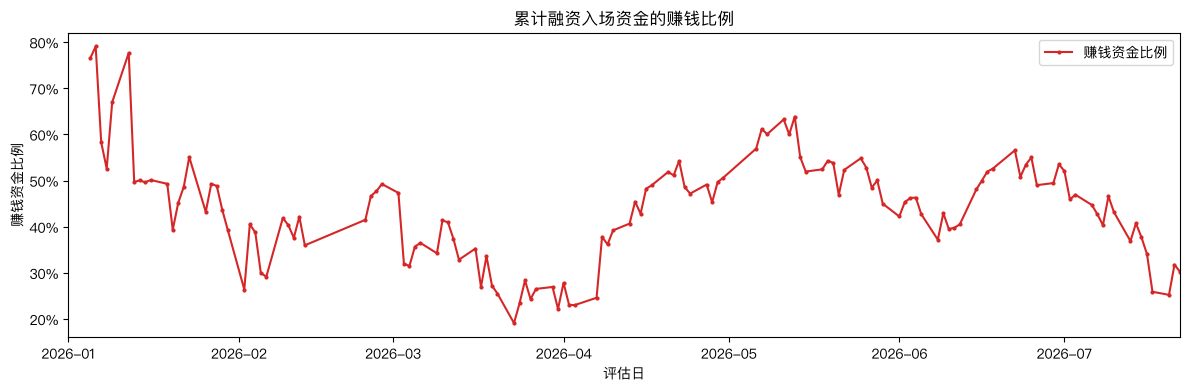

,evaluation_date,cumulative_entry_amount,profitable_amount,profit_ratio,profitable_batch_count,total_batch_count
127,2026-07-16,24406536356715,8318385885329,0.340826,37841,129156
128,2026-07-17,24550916844299,6362056874912,0.259137,29149,130159
129,2026-07-20,24699855692640,6235187538330,0.252438,29738,131162
130,2026-07-21,24892472163405,7916144943639,0.318014,35562,132165
131,2026-07-22,24892472163405,7525100991045,0.302304,34467,132165


In [5]:
positions = margin.merge(sample_keys, on=['exchange', 'security_code'], how='inner').merge(
    prices, on=['trade_date', 'exchange', 'security_code'], how='inner', validate='one_to_one'
)
positions = positions.loc[(positions.financing_buy_amount > 0) & (positions.volume > 0) & (positions.close_unadjusted > 0)].copy()
positions['entry_price'] = positions.amount / positions.volume * positions.close / positions.close_unadjusted
missing_price_keys = sample_keys.merge(prices[['exchange', 'security_code']].drop_duplicates(), on=['exchange', 'security_code'], how='left', indicator=True)
missing_price_keys = missing_price_keys.loc[missing_price_keys['_merge'].eq('left_only')].drop(columns='_merge')
display(pd.DataFrame({'样本证券数': [len(sample_keys)], '有行情证券数': [len(sample_keys) - len(missing_price_keys)], '无行情证券数': [len(missing_price_keys)]}))

evaluations = []
for evaluation_date, evaluation_prices in prices.groupby('trade_date', sort=True):
    current = positions.loc[positions.trade_date <= evaluation_date].merge(
        evaluation_prices[['exchange', 'security_code', 'close']].rename(columns={'close': 'close_evaluation'}),
        on=['exchange', 'security_code'],
        how='inner',
        validate='many_to_one',
    )
    if current.empty:
        continue
    current['security_return'] = current.close_evaluation / current.entry_price - 1
    current['profitable'] = current.security_return > 0
    total_amount = current.financing_buy_amount.sum()
    profitable_amount = current.loc[current.profitable, 'financing_buy_amount'].sum()
    evaluations.append({
        'evaluation_date': evaluation_date,
        'cumulative_entry_amount': total_amount,
        'profitable_amount': profitable_amount,
        'profit_ratio': profitable_amount / total_amount,
        'profitable_batch_count': current.profitable.sum(),
        'total_batch_count': len(current),
    })
profitability = pd.DataFrame(evaluations)
assert profitability.profit_ratio.between(0, 1).all()
profitability.to_parquet(DERIVED / 'all_security_profit_ratio.parquet', index=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(profitability.evaluation_date, profitability.profit_ratio, color='tab:red', marker='o', markersize=2, label='赚钱资金比例')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(pd.Timestamp('2026-01-01'), profitability.evaluation_date.max())
ax.set_title('累计融资入场资金的赚钱比例')
ax.set_xlabel('评估日')
ax.set_ylabel('赚钱资金比例')
ax.legend()
plt.tight_layout()
plt.show()
profitability.tail()